# Breast Cancer Diagnosis Prediction using Machine Learning

**Author:** YourName  
**Project:** Classifying breast tumours as *malignant* or *benign* from cell-nucleus measurements

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — UCI Machine Learning Repository  
https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic  
(a copy is bundled with scikit-learn, so no download is needed to run this notebook)

---
## Workflow
1. Load the data
2. Exploratory data analysis (EDA)
3. Train/test split and preprocessing
4. Baseline model comparison with cross-validation
5. Hyperparameter tuning
6. Final evaluation on the held-out test set
7. Feature importance
8. Save the model and summarise

## 1. Import Libraries

In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, classification_report)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load the Dataset
scikit-learn's built-in target encodes *malignant = 0* and *benign = 1*. To make the metrics easier to read, we flip it so that **malignant = 1 (the positive class)**. Recall on this class tells us how many real cancers we catch.

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df["diagnosis"] = 1 - df["target"]        # 1 = malignant, 0 = benign
df = df.drop(columns="target")

print("Shape:", df.shape)
df.head()

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## 3. Exploratory Data Analysis

In [3]:
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
df.describe().T.round(3).head(12)

Missing values: 0
Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
mean texture,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
mean perimeter,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
mean area,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
mean smoothness,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
mean compactness,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345
mean concavity,569.0,0.089,0.080,0.000,0.030,0.062,0.131,0.427
mean concave points,569.0,0.049,0.039,0.000,0.020,0.034,0.074,0.201
mean symmetry,569.0,0.181,0.027,0.106,0.162,0.179,0.196,0.304
mean fractal dimension,569.0,0.063,0.007,0.050,0.058,0.062,0.066,0.097


diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64 

diagnosis
Benign       62.7 %
Malignant    37.3 %
Name: count, dtype: str


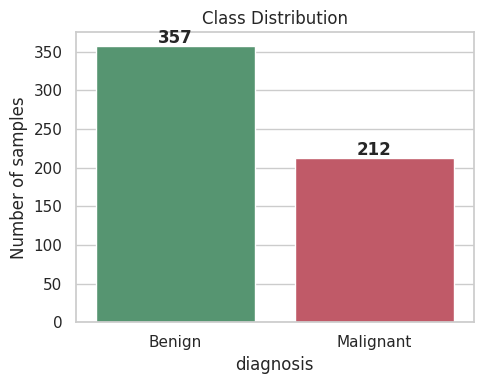

In [4]:
counts = df["diagnosis"].map({0: "Benign", 1: "Malignant"}).value_counts()
print(counts, "\n")
print((counts / len(df) * 100).round(1).astype(str) + " %")

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=["#4C9F70", "#D1495B"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 4, str(v), ha="center", fontweight="bold")
ax.set_title("Class Distribution"); ax.set_ylabel("Number of samples")
plt.tight_layout(); plt.savefig("figures/class_distribution.png", dpi=150); plt.show()

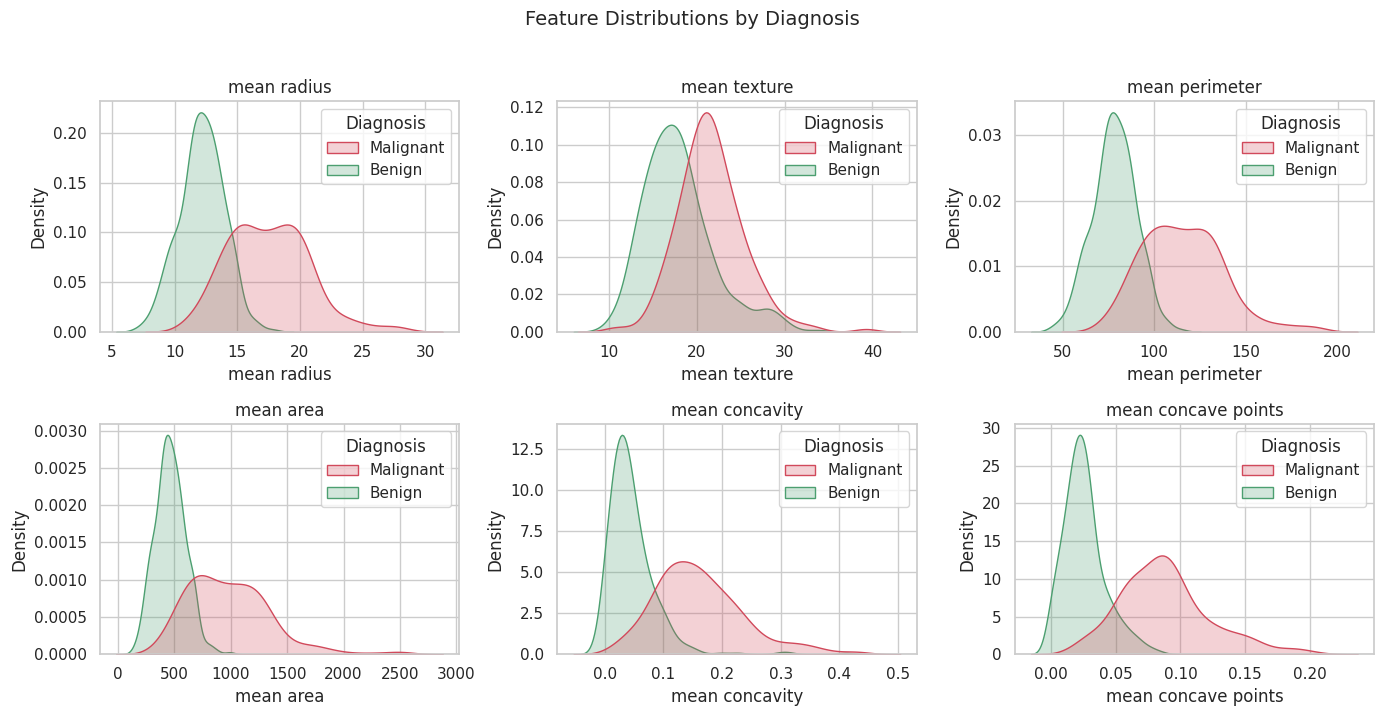

In [5]:
features = ["mean radius", "mean texture", "mean perimeter", "mean area",
            "mean concavity", "mean concave points"]
plot_df = df.copy()
plot_df["Diagnosis"] = plot_df["diagnosis"].map({0: "Benign", 1: "Malignant"})

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), features):
    sns.kdeplot(data=plot_df, x=col, hue="Diagnosis", fill=True, common_norm=False,
                palette={"Benign": "#4C9F70", "Malignant": "#D1495B"}, ax=ax)
    ax.set_title(col)
plt.suptitle("Feature Distributions by Diagnosis", fontsize=14, y=1.02)
plt.tight_layout(); plt.savefig("figures/feature_distributions.png", dpi=150, bbox_inches="tight"); plt.show()

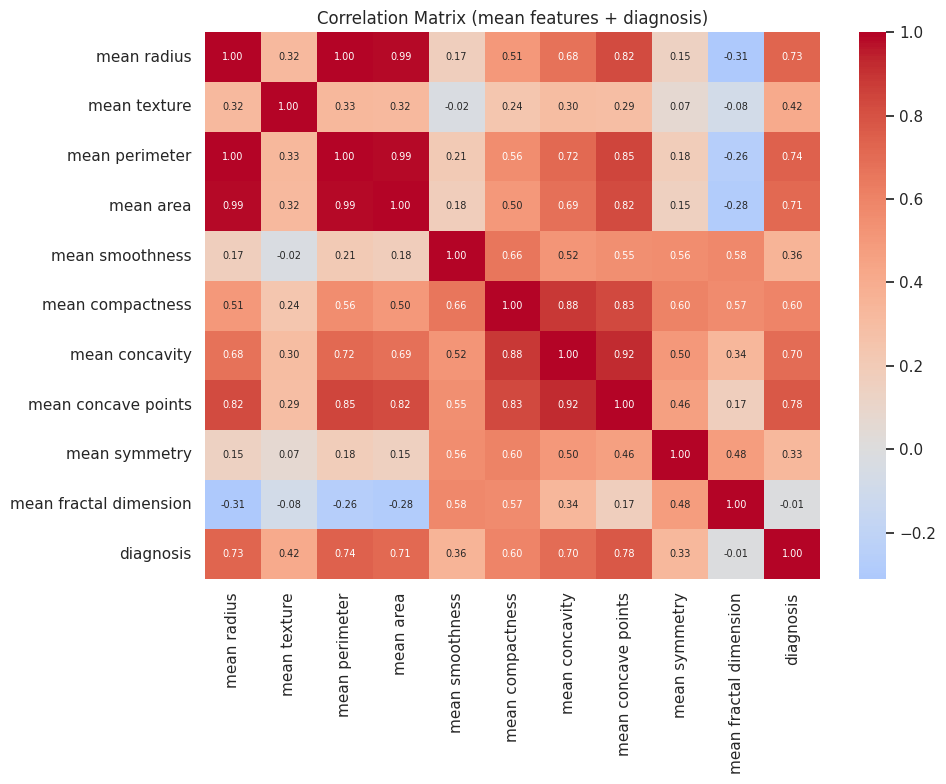

Top correlations with diagnosis:
worst concave points    0.794
worst perimeter         0.783
mean concave points     0.777
worst radius            0.776
mean perimeter          0.743
worst area              0.734
Name: diagnosis, dtype: float64


In [6]:
mean_cols = [c for c in df.columns if c.startswith("mean ")] + ["diagnosis"]
corr = df[mean_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 7})
plt.title("Correlation Matrix (mean features + diagnosis)")
plt.tight_layout(); plt.savefig("figures/correlation_heatmap.png", dpi=150); plt.show()

print("Top correlations with diagnosis:")
print(df.corr()["diagnosis"].drop("diagnosis").abs().sort_values(ascending=False).head(6).round(3))

**Observations**
- No missing values or duplicates, so no imputation is needed.
- The classes are moderately imbalanced (about 63% benign / 37% malignant), so we use *stratified* splits and look at recall and F1, not accuracy alone.
- Size- and shape-related features (radius, perimeter, area, concavity, concave points) separate the classes clearly.
- Many features are strongly correlated with each other (e.g. radius, perimeter and area), which suits regularised and tree-based models.

## 4. Train/Test Split

In [7]:
X = df.drop(columns="diagnosis")
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Malignant share  train: %.3f | test: %.3f" % (y_train.mean(), y_test.mean()))

Train: (455, 30), Test: (114, 30)
Malignant share  train: 0.374 | test: 0.368


## 5. Baseline Model Comparison
Each model is wrapped in a `Pipeline` with `StandardScaler`, so scaling is learned only from the training folds (no data leakage). We use 5-fold stratified cross-validation on the training set.

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "KNN":                 KNeighborsClassifier(),
    "SVM (RBF)":           SVC(probability=True, random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=RANDOM_STATE),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

rows = []
for name, model in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", model)])
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    rows.append({"Model": name, **{m.capitalize(): res[f"test_{m}"].mean() for m in scoring}})

cv_results = pd.DataFrame(rows).set_index("Model").round(4).sort_values("F1", ascending=False)
cv_results

,Accuracy,Precision,Recall,F1,Roc_auc
Model,,,,,
Logistic Regression,0.9736,0.9771,0.9529,0.9640,0.9958
SVM (RBF),0.9714,0.9769,0.9471,0.9610,0.9949
Gradient Boosting,0.9670,0.9646,0.9471,0.9553,0.9908
KNN,0.9648,0.9875,0.9176,0.9510,0.9871
Random Forest,0.9604,0.9584,0.9353,0.9461,0.9880


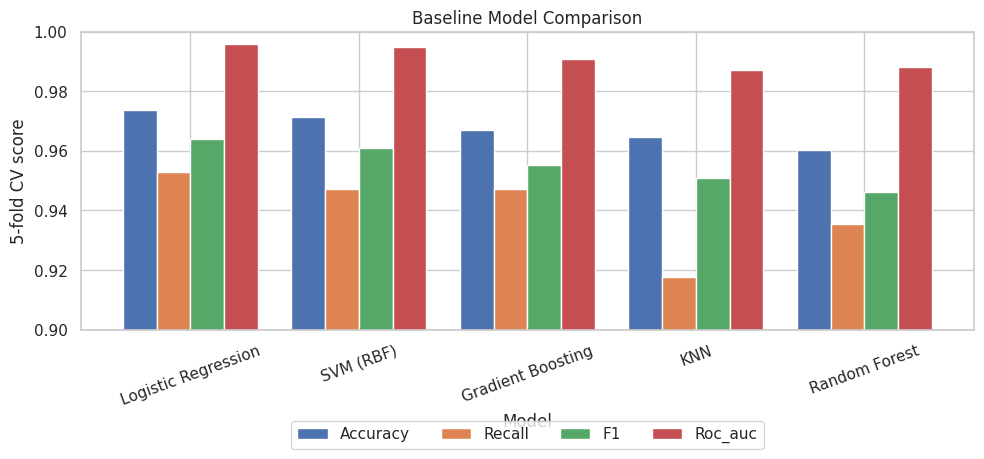

In [9]:
ax = cv_results[["Accuracy", "Recall", "F1", "Roc_auc"]].plot(kind="bar", figsize=(10, 5), width=0.8)
ax.set_ylim(0.9, 1.0); ax.set_ylabel("5-fold CV score"); ax.set_title("Baseline Model Comparison")
plt.xticks(rotation=20); plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=4)
plt.tight_layout(); plt.savefig("figures/model_comparison.png", dpi=150); plt.show()

## 6. Hyperparameter Tuning
We tune the two most promising model families with `GridSearchCV`, optimising **F1** (a balance of precision and recall on the malignant class).

In [10]:
search_spaces = {
    "SVM (RBF)": (
        Pipeline([("scaler", StandardScaler()), ("clf", SVC(probability=True, random_state=RANDOM_STATE))]),
        {"clf__C": [0.1, 1, 10, 100], "clf__gamma": ["scale", 0.01, 0.001]},
    ),
    "Logistic Regression": (
        Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))]),
        {"clf__C": [0.01, 0.1, 1, 10, 100]},
    ),
    "Random Forest": (
        Pipeline([("scaler", StandardScaler()), ("clf", RandomForestClassifier(random_state=RANDOM_STATE))]),
        {"clf__n_estimators": [200, 400], "clf__max_depth": [None, 6, 10], "clf__min_samples_leaf": [1, 2]},
    ),
}

tuned = {}
for name, (pipe, grid) in search_spaces.items():
    gs = GridSearchCV(pipe, grid, cv=cv, scoring="f1", n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned[name] = gs
    print(f"{name:20s} best CV F1 = {gs.best_score_:.4f} | params = {gs.best_params_}")

SVM (RBF)            best CV F1 = 0.9674 | params = {'clf__C': 10, 'clf__gamma': 'scale'}


Logistic Regression  best CV F1 = 0.9640 | params = {'clf__C': 1}


Random Forest        best CV F1 = 0.9516 | params = {'clf__max_depth': 6, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}


## 7. Final Evaluation on the Held-Out Test Set

In [11]:
def evaluate(model, X_te, y_te):
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    return {
        "Accuracy":  accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred),
        "Recall":    recall_score(y_te, pred),
        "F1":        f1_score(y_te, pred),
        "ROC-AUC":   roc_auc_score(y_te, proba),
    }

test_results = pd.DataFrame({name: evaluate(gs.best_estimator_, X_test, y_test)
                             for name, gs in tuned.items()}).T.round(4)
test_results

,Accuracy,Precision,Recall,F1,ROC-AUC
SVM (RBF),0.9737,1.000,0.9286,0.9630,0.9927
Logistic Regression,0.9649,0.975,0.9286,0.9512,0.9960
Random Forest,0.9649,1.000,0.9048,0.9500,0.9947


In [12]:
best_name = max(tuned, key=lambda n: tuned[n].best_score_)   # chosen on CV score only, not on the test set
best_model = tuned[best_name].best_estimator_
print("Selected model:", best_name)
print("Best parameters:", tuned[best_name].best_params_, "\n")

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["Benign", "Malignant"], digits=3))

Selected model: SVM (RBF)
Best parameters: {'clf__C': 10, 'clf__gamma': 'scale'} 

              precision    recall  f1-score   support

      Benign      0.960     1.000     0.980        72
   Malignant      1.000     0.929     0.963        42

    accuracy                          0.974       114
   macro avg      0.980     0.964     0.971       114
weighted avg      0.975     0.974     0.973       114



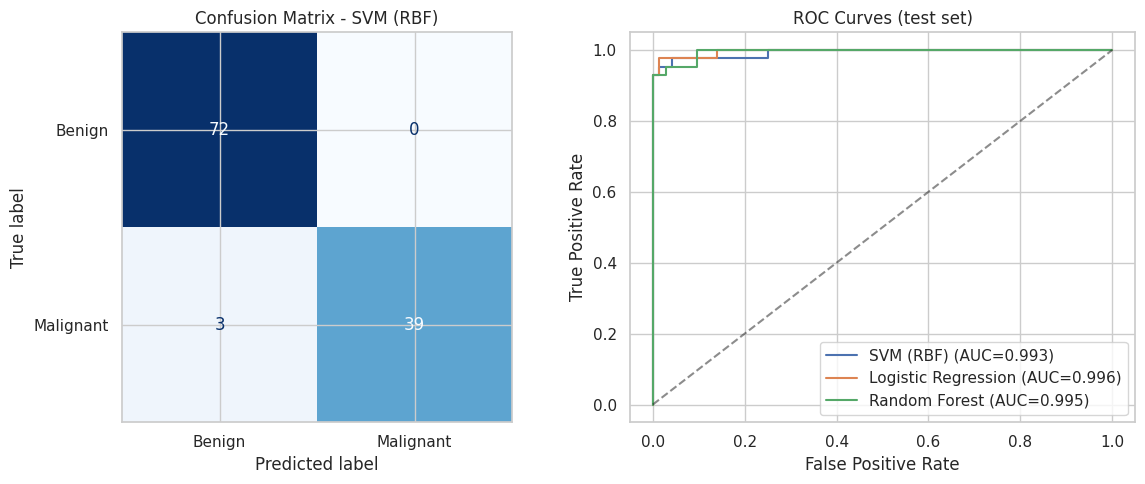

True negatives=72, False positives=0, False negatives=3, True positives=39


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix - {best_name}")

for name, gs in tuned.items():
    p = gs.best_estimator_.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, p):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves (test set)"); axes[1].legend(loc="lower right")

plt.tight_layout(); plt.savefig("figures/evaluation.png", dpi=150); plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"True negatives={tn}, False positives={fp}, False negatives={fn}, True positives={tp}")

## 8. Feature Importance
We use permutation importance on the test set, which works for any model: it measures how much the F1 score drops when a feature's values are shuffled.

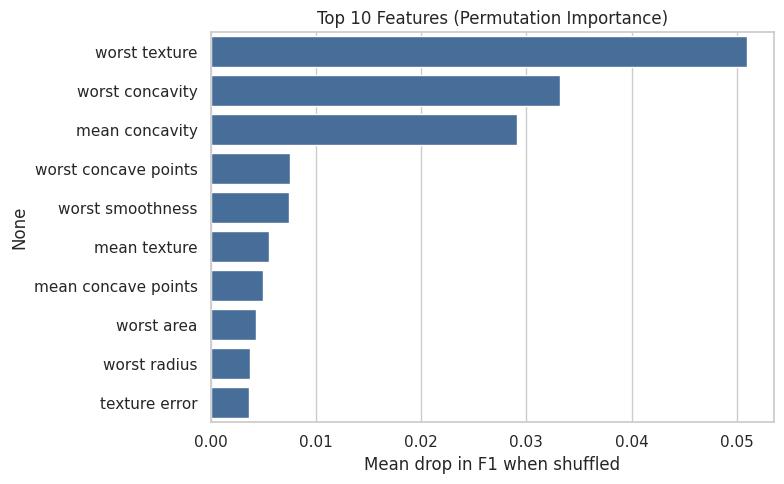

worst texture           0.0510
worst concavity         0.0332
mean concavity          0.0291
worst concave points    0.0075
worst smoothness        0.0074
mean texture            0.0055
mean concave points     0.0050
worst area              0.0043
worst radius            0.0037
texture error           0.0037
dtype: float64

In [14]:
perm = permutation_importance(best_model, X_test, y_test, scoring="f1",
                              n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1)
imp = (pd.Series(perm.importances_mean, index=X.columns)
         .sort_values(ascending=False).head(10))

plt.figure(figsize=(8, 5))
sns.barplot(x=imp.values, y=imp.index, color="#3A6EA5")
plt.xlabel("Mean drop in F1 when shuffled"); plt.title("Top 10 Features (Permutation Importance)")
plt.tight_layout(); plt.savefig("figures/feature_importance.png", dpi=150); plt.show()
imp.round(4)

## 9. Save the Model and Results

In [15]:
joblib.dump(best_model, "breast_cancer_model.joblib")

final = evaluate(best_model, X_test, y_test)
results = {
    "best_model": best_name,
    "best_params": {k: (v if v is None or isinstance(v, (int, float, str)) else str(v))
                    for k, v in tuned[best_name].best_params_.items()},
    "test_metrics": {k: round(float(v), 4) for k, v in final.items()},
    "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
    "cv_baseline": cv_results.reset_index().to_dict(orient="records"),
    "tuned_cv_f1": {n: round(float(g.best_score_), 4) for n, g in tuned.items()},
    "test_by_model": test_results.reset_index().rename(columns={"index": "Model"}).to_dict(orient="records"),
    "top_features": {k: round(float(v), 4) for k, v in imp.head(5).items()},
    "n_samples": int(len(df)), "n_features": int(X.shape[1]),
    "n_train": int(len(X_train)), "n_test": int(len(X_test)),
    "malignant_pct": round(float(y.mean() * 100), 1),
}
with open("results.json", "w") as f:
    json.dump(results, f, indent=2)
print(json.dumps(results["test_metrics"], indent=2))

{
  "Accuracy": 0.9737,
  "Precision": 1.0,
  "Recall": 0.9286,
  "F1": 0.963,
  "ROC-AUC": 0.9927
}


In [16]:
# Example: use the saved model on new data
loaded = joblib.load("breast_cancer_model.joblib")
sample = X_test.iloc[[0]]
label = {0: "Benign", 1: "Malignant"}
print("Predicted:", label[int(loaded.predict(sample)[0])],
      "| Actual:", label[int(y_test.iloc[0])],
      "| P(malignant) = %.3f" % loaded.predict_proba(sample)[0, 1])

Predicted: Benign | Actual: Benign | P(malignant) = 0.000


## 10. Conclusion
- Several standard classifiers reach more than 95% accuracy on this dataset once features are standardised.
- The final model was chosen by cross-validated F1 on the training data only, and then evaluated **once** on the held-out test set.
- In a screening context, *false negatives* (missed cancers) are the costliest error, so recall on the malignant class is the metric to watch alongside precision.
- Permutation importance ranks *worst texture*, *worst concavity* and *mean concavity* highest for the SVM. Individual importances are small because many features are correlated and carry overlapping information, so shuffling one is partly compensated by the others.
- On the test set the model produced no false positives but missed 3 of 42 malignant cases (recall about 93%), which is the main weakness to address.

**Limitations and next steps:** the dataset is small (569 samples), so results have some variance; further steps could include repeated cross-validation, probability calibration, threshold tuning to favour recall, and external validation on independent data.

> **Disclaimer:** this project is for educational purposes only and is not a medical diagnostic tool.